<a href="https://colab.research.google.com/github/XTMay/ML_DL/blob/main/CNN/fashion_mnist_tensorflow.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Fashion-MNIST CNN 分类器 - TensorFlow/Keras 实现

本教程将指导你使用 TensorFlow/Keras 构建一个卷积神经网络（CNN）来对 Fashion-MNIST 数据集进行分类。

## 学习目标
- 理解 Keras 的高级 API 在 CNN 构建中的优势
- 掌握 TensorFlow/Keras 中数据预处理和模型构建方法
- 学习 Keras 的回调函数和模型训练技巧
- 了解 TensorFlow 的模型保存和加载机制

Fashion-MNIST 是一个包含 10 种不同时尚物品的灰度图像数据集，每张图片大小为 28x28 像素。这 10 个类别分别是：T恤/上衣、裤子、套头衫、连衣裙、外套、凉鞋、衬衫、运动鞋、包、短靴。

## 1. 导入必要的库

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report
import warnings
warnings.filterwarnings('ignore')

# 配置 matplotlib 中文显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS', 'SimHei', 'DejaVu Sans']
plt.rcParams['axes.unicode_minus'] = False

# 设置随机种子以确保结果可复现
tf.random.set_seed(42)
np.random.seed(42)

# 检查 TensorFlow 版本和 GPU 可用性
print(f'TensorFlow 版本: {tf.__version__}')
print(f'可用 GPU 数量: {len(tf.config.list_physical_devices("GPU"))}')
if len(tf.config.list_physical_devices('GPU')) > 0:
    print('GPU 可用')
else:
    print('使用 CPU')

TensorFlow 版本: 2.19.0
可用 GPU 数量: 0
使用 CPU


## 2. 数据加载与预处理

Keras 提供了便捷的数据集加载功能，我们可以直接从 `keras.datasets` 加载 Fashion-MNIST 数据。

In [ ]:
# 加载 Fashion-MNIST 数据集
# Keras 自带数据集，会自动下载并缓存
(x_train, y_train), (x_test, y_test) = keras.datasets.fashion_mnist.load_data()

print(f'原始训练集形状: {x_train.shape}')
print(f'原始训练标签形状: {y_train.shape}')
print(f'原始测试集形状: {x_test.shape}')
print(f'原始测试标签形状: {y_test.shape}')
print(f'像素值范围: [{x_train.min()}, {x_train.max()}]')

# 数据预处理
# 1. 归一化像素值到 [0, 1] 范围
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# 2. 为单通道图像添加通道维度 (28, 28) -> (28, 28, 1)
x_train = np.expand_dims(x_train, axis=-1)
x_test = np.expand_dims(x_test, axis=-1)

# 3. 标签转换为 one-hot 编码
num_classes = 10
y_train_categorical = keras.utils.to_categorical(y_train, num_classes)
y_test_categorical = keras.utils.to_categorical(y_test, num_classes)

print(f'\n预处理后的数据形状:')
print(f'训练集: {x_train.shape}')
print(f'测试集: {x_test.shape}')
print(f'训练标签 (one-hot): {y_train_categorical.shape}')
print(f'测试标签 (one-hot): {y_test_categorical.shape}')
print(f'归一化后像素值范围: [{x_train.min():.3f}, {x_train.max():.3f}]')

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
原始训练集形状: (60000, 28, 28)
原始训练标签形状: (60000,)
原始测试集形状: (10000, 28, 28)
原始测试标签形状: (10000,)
像素值范围: [0, 255]

预处理后的数据形状:
训练集: (60000, 28, 28, 1)
测试集: (10000, 28, 28, 1)
训练标签 (one-hot): (60000, 10)
测试标签 (one-hot): (10000, 10)
归一化后像素值范围: [0.000, 1.000]


## 3. 数据集划分

将训练集进一步分割为训练集和验证集。

In [ ]:
# 分割训练集和验证集 (80:20)
from sklearn.model_selection import train_test_split

x_train_split, x_val, y_train_split, y_val = train_test_split(
    x_train, y_train_categorical, test_size=0.2, random_state=42, stratify=y_train
)

print(f'训练集大小: {x_train_split.shape[0]}')
print(f'验证集大小: {x_val.shape[0]}')
print(f'测试集大小: {x_test.shape[0]}')

# 保存原始标签用于后续分析
_, y_val_original = train_test_split(
    y_train, test_size=0.2, random_state=42, stratify=y_train
)

训练集大小: 48000
验证集大小: 12000
测试集大小: 10000


## 4. 探索性数据分析 (EDA)

让我们先了解一下数据集的基本信息，包括查看样本图像和类别分布。

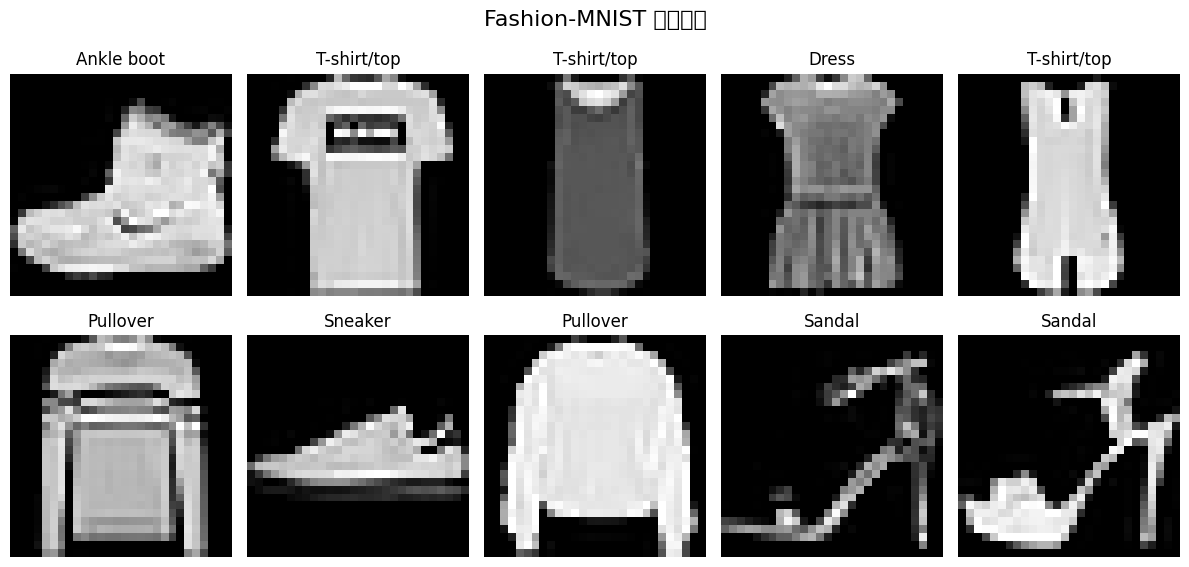

单张图像形状: (28, 28, 1)
图像数据类型: float32


In [ ]:
# Fashion-MNIST 的类别名称
class_names = ['T-shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat',
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 显示一些样本图像
def show_sample_images(images, labels, num_samples=10):
    fig, axes = plt.subplots(2, 5, figsize=(12, 6))
    fig.suptitle('Fashion-MNIST 样本图像', fontsize=16)

    for i in range(num_samples):
        row = i // 5
        col = i % 5

        # 显示图像（去掉通道维度）
        axes[row, col].imshow(images[i].squeeze(), cmap='gray')
        axes[row, col].set_title(f'{class_names[labels[i]]}')
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# 显示样本图像
show_sample_images(x_train, y_train)

# 检查图像形状
print(f'单张图像形状: {x_train[0].shape}')
print(f'图像数据类型: {x_train.dtype}')

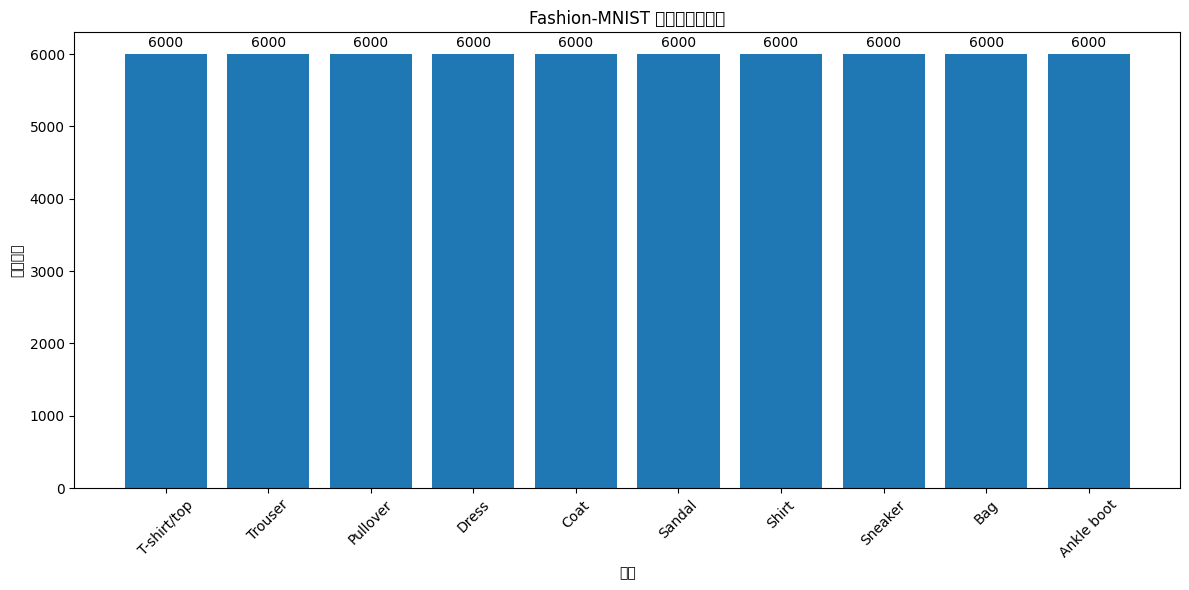

每个类别的样本数量:
T-shirt/top: 6000
Trouser: 6000
Pullover: 6000
Dress: 6000
Coat: 6000
Sandal: 6000
Shirt: 6000
Sneaker: 6000
Bag: 6000
Ankle boot: 6000


In [ ]:
# 分析类别分布
unique_labels, counts = np.unique(y_train, return_counts=True)

plt.figure(figsize=(12, 6))
bars = plt.bar([class_names[i] for i in unique_labels], counts)
plt.title('Fashion-MNIST 训练集类别分布')
plt.xlabel('类别')
plt.ylabel('样本数量')
plt.xticks(rotation=45)

# 在每个条形图上显示数值
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             str(count), ha='center', va='bottom')

plt.tight_layout()
plt.show()

print('每个类别的样本数量:')
for i, count in enumerate(counts):
    print(f'{class_names[i]}: {count}')

## 5. 构建 CNN 模型

使用 Keras 的函数式 API 构建 CNN 模型。这个模型包含三个卷积块，每个块包含卷积层、批标准化、激活函数和池化层。

In [ ]:
def create_cnn_model(input_shape=(28, 28, 1), num_classes=10, dropout_rate=0.5):
    """
    创建 CNN 模型

    Args:
        input_shape: 输入图像形状
        num_classes: 分类类别数
        dropout_rate: Dropout 比例

    Returns:
        compiled Keras model
    """
    # 输入层
    inputs = layers.Input(shape=input_shape)

    # 第一个卷积块
    # Conv2D(filters, kernel_size, padding, activation)
    x = layers.Conv2D(32, (3, 3), padding='same')(inputs)
    x = layers.BatchNormalization()(x)  # 批标准化提高训练稳定性
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)  # 最大池化，尺寸减半

    # 第二个卷积块
    x = layers.Conv2D(64, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # 第三个卷积块
    x = layers.Conv2D(128, (3, 3), padding='same')(x)
    x = layers.BatchNormalization()(x)
    x = layers.ReLU()(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # 全连接层
    x = layers.Flatten()(x)  # 展平特征图
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(dropout_rate)(x)  # Dropout 防止过拟合

    # 输出层
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    # 创建模型
    model = models.Model(inputs=inputs, outputs=outputs)

    return model

# 创建模型
model = create_cnn_model()

# 打印模型结构
model.summary()

# 计算模型参数数量
total_params = model.count_params()
print(f'\n总参数数量: {total_params:,}')

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 28, 28, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 14, 14, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 128)      │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 7, 7, 128)      │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_2 (ReLU)                  │ (None, 7, 7, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │         2,570 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 391,306 (1.49 MB)

 Trainable params: 390,858 (1.49 MB)

 Non-trainable params: 448 (1.75 KB)


总参数数量: 391,306


## 6. 编译模型

设置优化器、损失函数和评价指标。

In [ ]:
# 编译模型
# Adam 优化器是一个自适应学习率的优化算法
# categorical_crossentropy 用于多分类问题
# accuracy 用于监控训练过程中的准确率
model.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print('模型编译完成')
print(f'优化器: Adam (学习率: 0.001)')
print(f'损失函数: categorical_crossentropy')
print(f'评价指标: accuracy')

模型编译完成
优化器: Adam (学习率: 0.001)
损失函数: categorical_crossentropy
评价指标: accuracy


## 7. 设置训练回调函数

Keras 提供了强大的回调函数机制，用于在训练过程中执行特定操作。

In [ ]:
# 创建回调函数列表
callback_list = [
    # 模型检查点：保存最佳模型
    callbacks.ModelCheckpoint(
        filepath='best_fashion_cnn_tensorflow.h5',
        monitor='val_accuracy',  # 监控验证准确率
        save_best_only=True,     # 只保存最佳模型
        save_weights_only=False, # 保存完整模型
        verbose=1
    ),

    # 早停：如果验证准确率不再提升，提前停止训练
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,              # 连续 5 个 epoch 无改善时停止
        restore_best_weights=True,
        verbose=1
    ),

    # 学习率调度：当验证损失停止改善时减少学习率
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,              # 学习率减少因子
        patience=3,              # 等待 3 个 epoch
        min_lr=1e-6,            # 最小学习率
        verbose=1
    )
]

print('回调函数设置完成:')
for i, callback in enumerate(callback_list, 1):
    print(f'{i}. {callback.__class__.__name__}')

回调函数设置完成:
1. ModelCheckpoint
2. EarlyStopping
3. ReduceLROnPlateau


## 8. 模型训练

开始训练模型，Keras 的 `fit` 方法提供了简洁的训练接口。

In [ ]:
# 训练参数
batch_size = 64
epochs = 15

print(f'开始训练，共 {epochs} 个 epoch...')
print(f'批次大小: {batch_size}')
print('=' * 60)

# 开始训练
history = model.fit(
    x_train_split, y_train_split,
    batch_size=batch_size,
    epochs=epochs,
    validation_data=(x_val, y_val),
    callbacks=callback_list,
    verbose=1  # 显示详细的训练进度
)

print('\n训练完成！')

开始训练，共 15 个 epoch...
批次大小: 64
Epoch 1/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 146ms/step - accuracy: 0.7440 - loss: 0.7349
Epoch 1: val_accuracy improved from -inf to 0.87750, saving model to best_fashion_cnn_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 120s 154ms/step - accuracy: 0.7441 - loss: 0.7346 - val_accuracy: 0.8775 - val_loss: 0.3291 - learning_rate: 0.0010
Epoch 2/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8738 - loss: 0.3505
Epoch 2: val_accuracy improved from 0.87750 to 0.89750, saving model to best_fashion_cnn_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 140s 152ms/step - accuracy: 0.8738 - loss: 0.3505 - val_accuracy: 0.8975 - val_loss: 0.2810 - learning_rate: 0.0010
Epoch 3/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.8962 - loss: 0.2923
Epoch 3: val_accuracy did not improve from 0.89750
750/750 ━━━━━━━━━━━━━━━━━━━━ 118s 158ms/step - accuracy: 0.8962 - loss: 0.2923 - val_accuracy: 0.8889 - val_loss: 0.3076 - learning_rate: 0.0010
Epoch 4/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 143ms/step - accuracy: 0.9092 - loss: 0.2560
Epoch 4: val_accuracy improved from 0.89750 to 0.90150, saving model to best_fashion_cnn_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 139s 153ms/step - accuracy: 0.9092 - loss: 0.2560 - val_accuracy: 0.9015 - val_loss: 0.2807 - learning_rate: 0.0010
Epoch 5/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9154 - loss: 0.2322
Epoch 5: val_accuracy improved from 0.90150 to 0.91883, saving model to best_fashion_cnn_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 118s 158ms/step - accuracy: 0.9154 - loss: 0.2322 - val_accuracy: 0.9188 - val_loss: 0.2295 - learning_rate: 0.0010
Epoch 6/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9251 - loss: 0.2056
Epoch 6: val_accuracy did not improve from 0.91883
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 158ms/step - accuracy: 0.9251 - loss: 0.2056 - val_accuracy: 0.8995 - val_loss: 0.2841 - learning_rate: 0.0010
Epoch 7/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9317 - loss: 0.1880
Epoch 7: val_accuracy did not improve from 0.91883
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 159ms/step - accuracy: 0.9317 - loss: 0.1880 - val_accuracy: 0.8823 - val_loss: 0.3373 - learning_rate: 0.0010
Epoch 8/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9371 - loss: 0.1695
Epoch 8: val_accuracy did not improve from 0.91883

Epoch 8: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 158ms/step - accuracy: 0.9371 - loss

750/750 ━━━━━━━━━━━━━━━━━━━━ 137s 152ms/step - accuracy: 0.9505 - loss: 0.1370 - val_accuracy: 0.9258 - val_loss: 0.2379 - learning_rate: 2.0000e-04
Epoch 10/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9616 - loss: 0.1052
Epoch 10: val_accuracy improved from 0.92583 to 0.92958, saving model to best_fashion_cnn_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 144s 155ms/step - accuracy: 0.9616 - loss: 0.1052 - val_accuracy: 0.9296 - val_loss: 0.2348 - learning_rate: 2.0000e-04
Epoch 11/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 145ms/step - accuracy: 0.9669 - loss: 0.0891
Epoch 11: val_accuracy did not improve from 0.92958

Epoch 11: ReduceLROnPlateau reducing learning rate to 4.0000001899898055e-05.
750/750 ━━━━━━━━━━━━━━━━━━━━ 114s 152ms/step - accuracy: 0.9669 - loss: 0.0891 - val_accuracy: 0.9292 - val_loss: 0.2546 - learning_rate: 2.0000e-04
Epoch 12/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9718 - loss: 0.0769
Epoch 12: val_accuracy improved from 0.92958 to 0.93308, saving model to best_fashion_cnn_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 119s 158ms/step - accuracy: 0.9718 - loss: 0.0769 - val_accuracy: 0.9331 - val_loss: 0.2280 - learning_rate: 4.0000e-05
Epoch 13/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9751 - loss: 0.0695
Epoch 13: val_accuracy did not improve from 0.93308
750/750 ━━━━━━━━━━━━━━━━━━━━ 118s 157ms/step - accuracy: 0.9751 - loss: 0.0695 - val_accuracy: 0.9313 - val_loss: 0.2329 - learning_rate: 4.0000e-05
Epoch 14/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9758 - loss: 0.0655
Epoch 14: val_accuracy did not improve from 0.93308
750/750 ━━━━━━━━━━━━━━━━━━━━ 139s 154ms/step - accuracy: 0.9758 - loss: 0.0655 - val_accuracy: 0.9328 - val_loss: 0.2334 - learning_rate: 4.0000e-05
Epoch 15/15
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 144ms/step - accuracy: 0.9775 - loss: 0.0641
Epoch 15: val_accuracy did not improve from 0.93308

Epoch 15: ReduceLROnPlateau reducing learning rate to 8.000000525498762e-06.
750/750 ━━━━━━━━━━━━━━━━━━━━ 114s 152ms/step - accur

## 9. 训练历史可视化

绘制训练过程中的损失和准确率变化曲线。

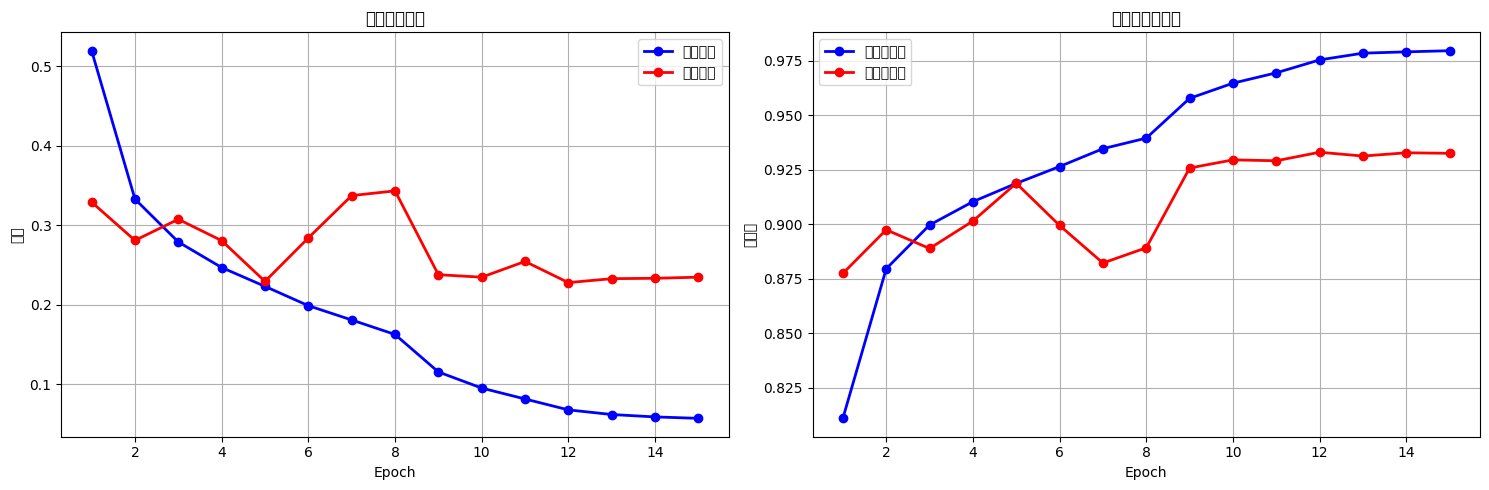

最终训练损失: 0.0574
最终验证损失: 0.2348
最终训练准确率: 0.9797 (97.97%)
最终验证准确率: 0.9326 (93.26%)
最佳验证准确率: 0.9331 (93.31%)


In [ ]:
# 提取训练历史
train_loss = history.history['loss']
val_loss = history.history['val_loss']
train_accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

epochs_range = range(1, len(train_loss) + 1)

# 绘制训练历史
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 损失曲线
ax1.plot(epochs_range, train_loss, 'bo-', label='训练损失', linewidth=2)
ax1.plot(epochs_range, val_loss, 'ro-', label='验证损失', linewidth=2)
ax1.set_title('模型损失变化')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('损失')
ax1.legend()
ax1.grid(True)

# 准确率曲线
ax2.plot(epochs_range, train_accuracy, 'bo-', label='训练准确率', linewidth=2)
ax2.plot(epochs_range, val_accuracy, 'ro-', label='验证准确率', linewidth=2)
ax2.set_title('模型准确率变化')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('准确率')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

# 打印最终结果
print(f'最终训练损失: {train_loss[-1]:.4f}')
print(f'最终验证损失: {val_loss[-1]:.4f}')
print(f'最终训练准确率: {train_accuracy[-1]:.4f} ({train_accuracy[-1]*100:.2f}%)')
print(f'最终验证准确率: {val_accuracy[-1]:.4f} ({val_accuracy[-1]*100:.2f}%)')
print(f'最佳验证准确率: {max(val_accuracy):.4f} ({max(val_accuracy)*100:.2f}%)')

## 10. 模型评估

加载最佳模型并在测试集上进行评估。

In [ ]:
# 加载最佳模型
best_model = keras.models.load_model('best_fashion_cnn_tensorflow.h5')
print('最佳模型加载成功')

# 在测试集上评估
test_loss, test_accuracy = best_model.evaluate(x_test, y_test_categorical, verbose=1)
print(f'\n测试集损失: {test_loss:.4f}')
print(f'测试集准确率: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)')

# 获取测试集预测结果
y_pred = best_model.predict(x_test, verbose=1)
y_pred_classes = np.argmax(y_pred, axis=1)

print(f'\n预测完成，预测结果形状: {y_pred.shape}')

最佳模型加载成功
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 19ms/step - accuracy: 0.9213 - loss: 0.2685

测试集损失: 0.2581
测试集准确率: 0.9237 (92.37%)
313/313 ━━━━━━━━━━━━━━━━━━━━ 6s 18ms/step

预测完成，预测结果形状: (10000, 10)


## 11. 详细分类报告

生成详细的分类性能报告。

In [ ]:
# 生成分类报告
print('详细分类报告:')
print('=' * 80)
print(classification_report(y_test, y_pred_classes, target_names=class_names))

# 计算各类别准确率
from sklearn.metrics import accuracy_score
overall_accuracy = accuracy_score(y_test, y_pred_classes)
print(f'\n总体准确率: {overall_accuracy:.4f} ({overall_accuracy*100:.2f}%)')

详细分类报告:
              precision    recall  f1-score   support

 T-shirt/top       0.88      0.87      0.87      1000
     Trouser       0.99      0.98      0.99      1000
    Pullover       0.89      0.88      0.88      1000
       Dress       0.93      0.91      0.92      1000
        Coat       0.87      0.90      0.88      1000
      Sandal       0.98      0.99      0.99      1000
       Shirt       0.77      0.78      0.78      1000
     Sneaker       0.96      0.97      0.97      1000
         Bag       0.99      0.99      0.99      1000
  Ankle boot       0.98      0.97      0.97      1000

    accuracy                           0.92     10000
   macro avg       0.92      0.92      0.92     10000
weighted avg       0.92      0.92      0.92     10000


总体准确率: 0.9237 (92.37%)


## 12. 混淆矩阵可视化

绘制混淆矩阵来分析模型在各个类别上的表现。

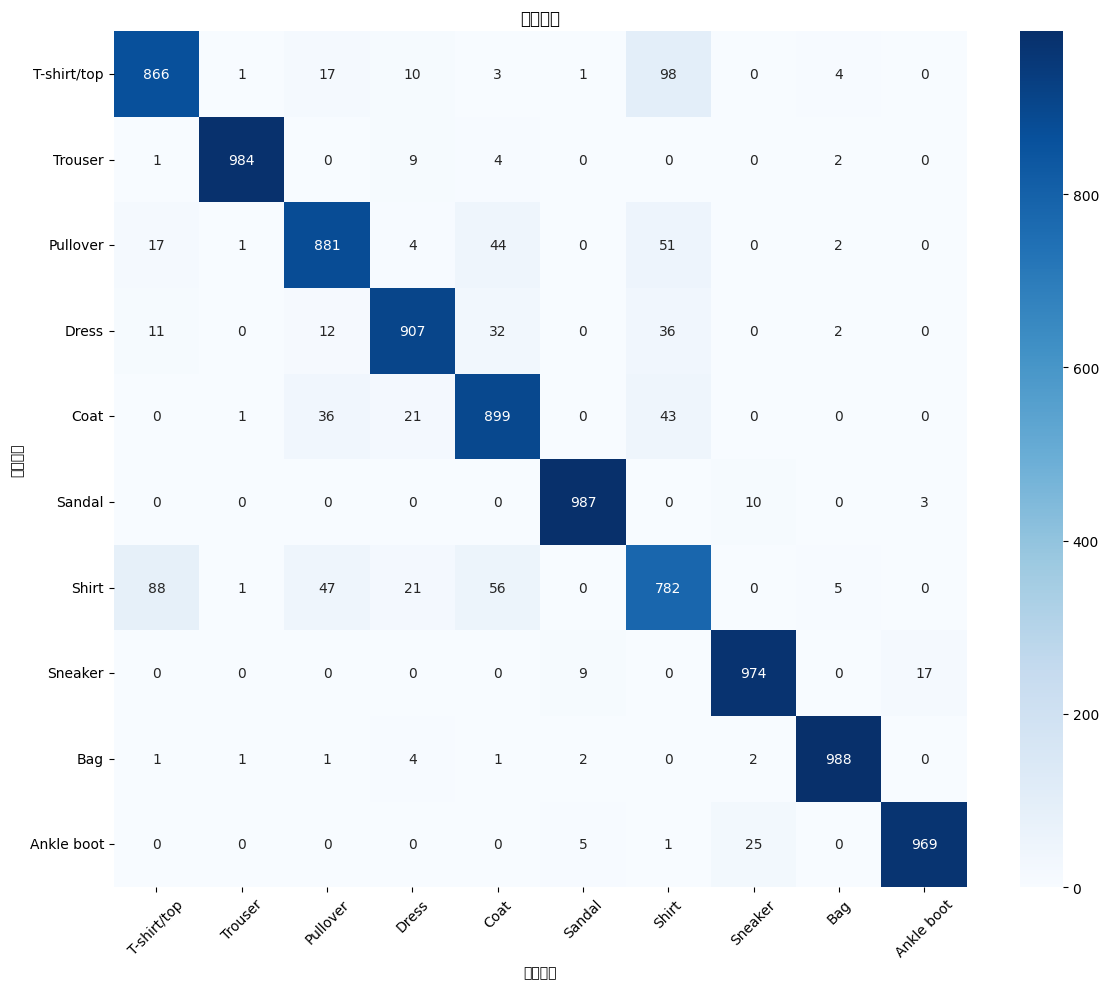


每个类别的准确率:
----------------------------------------
T-shirt/top    : 0.866 (86.6%)
Trouser        : 0.984 (98.4%)
Pullover       : 0.881 (88.1%)
Dress          : 0.907 (90.7%)
Coat           : 0.899 (89.9%)
Sandal         : 0.987 (98.7%)
Shirt          : 0.782 (78.2%)
Sneaker        : 0.974 (97.4%)
Bag            : 0.988 (98.8%)
Ankle boot     : 0.969 (96.9%)

表现最好的类别: Bag (98.8%)
表现最差的类别: Shirt (78.2%)


In [ ]:
# 计算混淆矩阵
cm = confusion_matrix(y_test, y_pred_classes)

# 绘制混淆矩阵
plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('混淆矩阵')
plt.xlabel('预测类别')
plt.ylabel('真实类别')
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 计算每个类别的准确率
class_accuracy = cm.diagonal() / cm.sum(axis=1)
print('\n每个类别的准确率:')
print('-' * 40)
for i, acc in enumerate(class_accuracy):
    print(f'{class_names[i]:15s}: {acc:.3f} ({acc*100:.1f}%)')

# 找出表现最好和最差的类别
best_class_idx = np.argmax(class_accuracy)
worst_class_idx = np.argmin(class_accuracy)
print(f'\n表现最好的类别: {class_names[best_class_idx]} ({class_accuracy[best_class_idx]*100:.1f}%)')
print(f'表现最差的类别: {class_names[worst_class_idx]} ({class_accuracy[worst_class_idx]*100:.1f}%)')

## 13. 错误预测分析

分析一些模型预测错误的样本，帮助理解模型的局限性。

预测错误的样本数量: 763


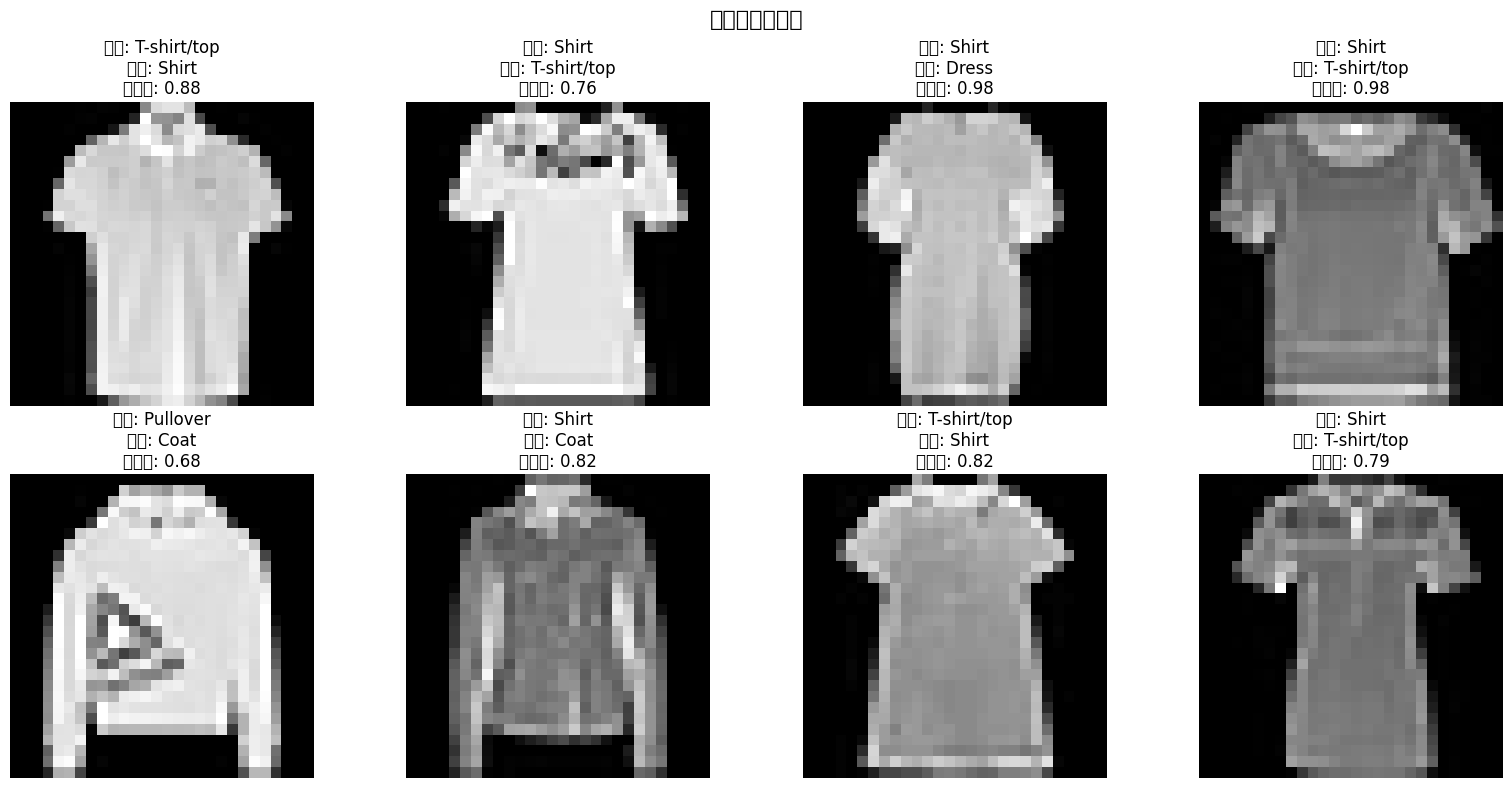

In [ ]:
# 找出预测错误的样本
incorrect_indices = np.where(y_pred_classes != y_test)[0]
print(f'预测错误的样本数量: {len(incorrect_indices)}')

# 显示一些错误预测的样本
def show_misclassified_images(images, true_labels, pred_labels, pred_probs,
                            incorrect_indices, num_images=8):
    """显示错误分类的图像"""
    if len(incorrect_indices) < num_images:
        num_images = len(incorrect_indices)

    # 随机选择一些错误样本
    selected_indices = np.random.choice(incorrect_indices, num_images, replace=False)

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))
    fig.suptitle('错误分类的样本', fontsize=16)

    for i, idx in enumerate(selected_indices):
        row = i // 4
        col = i % 4

        # 显示图像
        axes[row, col].imshow(images[idx].squeeze(), cmap='gray')

        # 获取预测置信度
        confidence = pred_probs[idx][pred_labels[idx]]

        axes[row, col].set_title(
            f'真实: {class_names[true_labels[idx]]}\n'
            f'预测: {class_names[pred_labels[idx]]}\n'
            f'置信度: {confidence:.2f}'
        )
        axes[row, col].axis('off')

    plt.tight_layout()
    plt.show()

# 显示错误分类的样本
show_misclassified_images(x_test, y_test, y_pred_classes, y_pred, incorrect_indices)

## 14. 模型微调 - 数据增强

使用 Keras 的 `ImageDataGenerator` 进行数据增强，提高模型的泛化能力。

In [ ]:
# 创建数据增强生成器
datagen = ImageDataGenerator(
    rotation_range=10,      # 随机旋转角度范围
    width_shift_range=0.1,  # 随机水平平移
    height_shift_range=0.1, # 随机垂直平移
    horizontal_flip=True,   # 随机水平翻转
    zoom_range=0.1         # 随机缩放
)

print('数据增强配置:')
print('- 随机旋转: ±10度')
print('- 水平/垂直平移: ±10%')
print('- 水平翻转: 50%概率')
print('- 随机缩放: ±10%')

# 创建新的模型进行数据增强训练
model_augmented = create_cnn_model(dropout_rate=0.5)
model_augmented.compile(
    optimizer=optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 设置新的回调函数
callback_list_aug = [
    callbacks.ModelCheckpoint(
        filepath='best_fashion_cnn_augmented_tensorflow.h5',
        monitor='val_accuracy',
        save_best_only=True,
        verbose=1
    ),
    callbacks.EarlyStopping(
        monitor='val_accuracy',
        patience=5,
        restore_best_weights=True,
        verbose=1
    ),
    callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.2,
        patience=3,
        min_lr=1e-6,
        verbose=1
    )
]

print('\n开始数据增强训练...')
print('=' * 60)

# 使用数据增强进行训练（减少 epoch 数以节省时间）
history_augmented = model_augmented.fit(
    datagen.flow(x_train_split, y_train_split, batch_size=batch_size),
    steps_per_epoch=len(x_train_split) // batch_size,
    epochs=10,  # 减少 epoch 数
    validation_data=(x_val, y_val),
    callbacks=callback_list_aug,
    verbose=1
)

print('\n数据增强训练完成！')

数据增强配置:
- 随机旋转: ±10度
- 水平/垂直平移: ±10%
- 水平翻转: 50%概率
- 随机缩放: ±10%

开始数据增强训练...
Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.6558 - loss: 0.9674
Epoch 1: val_accuracy improved from -inf to 0.82833, saving model to best_fashion_cnn_augmented_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 136s 177ms/step - accuracy: 0.6559 - loss: 0.9671 - val_accuracy: 0.8283 - val_loss: 0.4455 - learning_rate: 0.0010
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.7962 - loss: 0.5430
Epoch 2: val_accuracy improved from 0.82833 to 0.84092, saving model to best_fashion_cnn_augmented_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 178ms/step - accuracy: 0.7962 - loss: 0.5430 - val_accuracy: 0.8409 - val_loss: 0.4045 - learning_rate: 0.0010
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 168ms/step - accuracy: 0.8245 - loss: 0.4801
Epoch 3: val_accuracy improved from 0.84092 to 0.87242, saving model to best_fashion_cnn_augmented_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 177ms/step - accuracy: 0.8246 - loss: 0.4800 - val_accuracy: 0.8724 - val_loss: 0.3414 - learning_rate: 0.0010
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8409 - loss: 0.4320
Epoch 4: val_accuracy did not improve from 0.87242
750/750 ━━━━━━━━━━━━━━━━━━━━ 143s 179ms/step - accuracy: 0.8409 - loss: 0.4320 - val_accuracy: 0.8457 - val_loss: 0.3920 - learning_rate: 0.0010
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 169ms/step - accuracy: 0.8546 - loss: 0.3954
Epoch 5: val_accuracy improved from 0.87242 to 0.89000, saving model to best_fashion_cnn_augmented_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 134s 178ms/step - accuracy: 0.8546 - loss: 0.3954 - val_accuracy: 0.8900 - val_loss: 0.3013 - learning_rate: 0.0010
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 166ms/step - accuracy: 0.8579 - loss: 0.3834
Epoch 6: val_accuracy did not improve from 0.89000
750/750 ━━━━━━━━━━━━━━━━━━━━ 135s 180ms/step - accuracy: 0.8579 - loss: 0.3834 - val_accuracy: 0.8852 - val_loss: 0.3160 - learning_rate: 0.0010
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8701 - loss: 0.3556
Epoch 7: val_accuracy did not improve from 0.89000
750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 178ms/step - accuracy: 0.8701 - loss: 0.3556 - val_accuracy: 0.8680 - val_loss: 0.3517 - learning_rate: 0.0010
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8720 - loss: 0.3511
Epoch 8: val_accuracy improved from 0.89000 to 0.89942, saving model to best_fashion_cnn_augmented_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 130s 173ms/step - accuracy: 0.8720 - loss: 0.3511 - val_accuracy: 0.8994 - val_loss: 0.2729 - learning_rate: 0.0010
Epoch 9/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 165ms/step - accuracy: 0.8779 - loss: 0.3339
Epoch 9: val_accuracy did not improve from 0.89942
750/750 ━━━━━━━━━━━━━━━━━━━━ 142s 173ms/step - accuracy: 0.8779 - loss: 0.3339 - val_accuracy: 0.8957 - val_loss: 0.2882 - learning_rate: 0.0010
Epoch 10/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.8825 - loss: 0.3289
Epoch 10: val_accuracy improved from 0.89942 to 0.90542, saving model to best_fashion_cnn_augmented_tensorflow.h5


750/750 ━━━━━━━━━━━━━━━━━━━━ 141s 173ms/step - accuracy: 0.8825 - loss: 0.3289 - val_accuracy: 0.9054 - val_loss: 0.2563 - learning_rate: 0.0010
Restoring model weights from the end of the best epoch: 10.

数据增强训练完成！


## 15. 比较模型性能

比较原始模型和数据增强模型的性能。

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 22ms/step - accuracy: 0.8964 - loss: 0.2901

模型性能比较:
原始模型测试准确率: 92.37%
数据增强模型测试准确率: 89.45%
性能提升: -2.92%


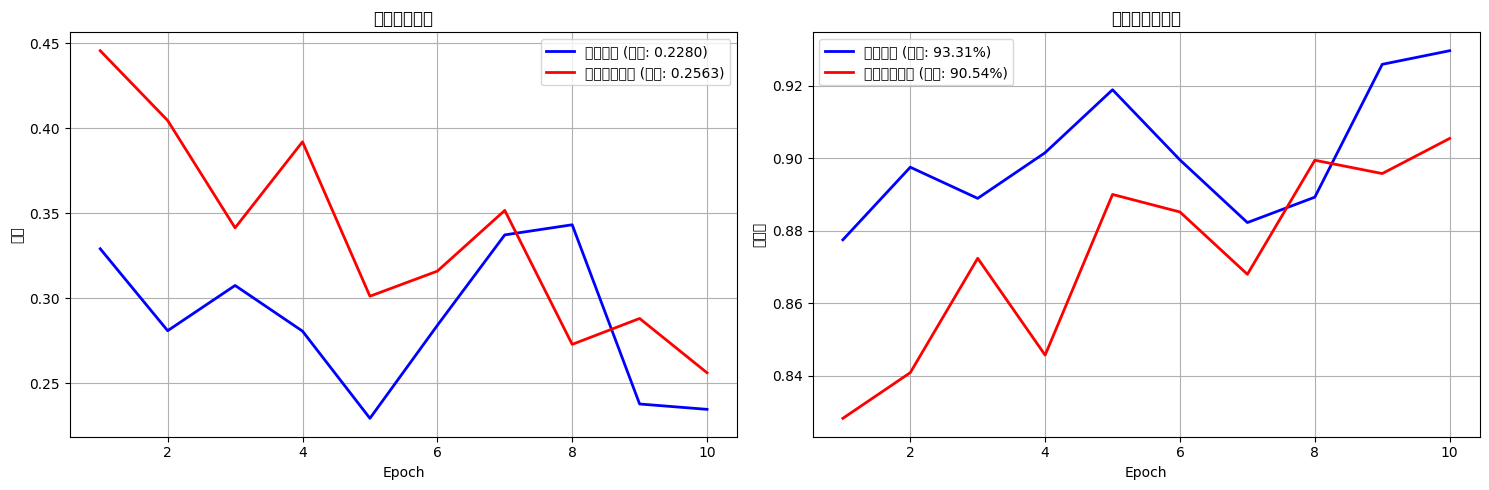

In [ ]:
# 加载并测试数据增强模型
best_model_augmented = keras.models.load_model('best_fashion_cnn_augmented_tensorflow.h5')
test_loss_aug, test_accuracy_aug = best_model_augmented.evaluate(
    x_test, y_test_categorical, verbose=1
)

# 性能比较
print('\n模型性能比较:')
print('=' * 50)
print(f'原始模型测试准确率: {test_accuracy*100:.2f}%')
print(f'数据增强模型测试准确率: {test_accuracy_aug*100:.2f}%')
print(f'性能提升: {(test_accuracy_aug - test_accuracy)*100:+.2f}%')

# 提取数据增强模型的训练历史
train_loss_aug = history_augmented.history['loss']
val_loss_aug = history_augmented.history['val_loss']
train_accuracy_aug = history_augmented.history['accuracy']
val_accuracy_aug = history_augmented.history['val_accuracy']

# 绘制性能比较图
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(15, 5))

# 验证损失比较（只比较相同长度的部分）
min_epochs = min(len(val_loss), len(val_loss_aug))
epochs_range_comp = range(1, min_epochs + 1)

ax1.plot(epochs_range_comp, val_loss[:min_epochs], 'b-',
         label=f'原始模型 (最佳: {min(val_loss):.4f})', linewidth=2)
ax1.plot(epochs_range_comp, val_loss_aug[:min_epochs], 'r-',
         label=f'数据增强模型 (最佳: {min(val_loss_aug):.4f})', linewidth=2)
ax1.set_title('验证损失比较')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('损失')
ax1.legend()
ax1.grid(True)

# 验证准确率比较
ax2.plot(epochs_range_comp, val_accuracy[:min_epochs], 'b-',
         label=f'原始模型 (最佳: {max(val_accuracy)*100:.2f}%)', linewidth=2)
ax2.plot(epochs_range_comp, val_accuracy_aug[:min_epochs], 'r-',
         label=f'数据增强模型 (最佳: {max(val_accuracy_aug)*100:.2f}%)', linewidth=2)
ax2.set_title('验证准确率比较')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('准确率')
ax2.legend()
ax2.grid(True)

plt.tight_layout()
plt.show()

## 16. 模型微调 - 不同优化器实验

尝试不同的优化器来进一步优化模型性能。

In [ ]:
# 测试不同优化器的效果
optimizers_to_test = {
    'Adam': optimizers.Adam(learning_rate=0.001),
    'RMSprop': optimizers.RMSprop(learning_rate=0.001),
    'SGD': optimizers.SGD(learning_rate=0.01, momentum=0.9)
}

optimizer_results = {}

for optimizer_name, optimizer in optimizers_to_test.items():
    print(f'\n测试优化器: {optimizer_name}')
    print('=' * 40)

    # 创建新模型
    model_opt = create_cnn_model(dropout_rate=0.5)
    model_opt.compile(
        optimizer=optimizer,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    # 快速训练 5 个 epoch
    history_opt = model_opt.fit(
        x_train_split, y_train_split,
        batch_size=batch_size,
        epochs=5,
        validation_data=(x_val, y_val),
        verbose=0  # 静默训练
    )

    best_val_acc = max(history_opt.history['val_accuracy'])
    optimizer_results[optimizer_name] = best_val_acc
    print(f'最佳验证准确率: {best_val_acc:.4f} ({best_val_acc*100:.2f}%)')

# 显示优化器实验结果
print('\n优化器实验结果:')
print('=' * 30)
for optimizer_name, acc in optimizer_results.items():
    print(f'{optimizer_name:10s}: {acc:.4f} ({acc*100:.2f}%)')

# 找到最佳优化器
best_optimizer = max(optimizer_results, key=optimizer_results.get)
print(f'\n最佳优化器: {best_optimizer} (准确率: {optimizer_results[best_optimizer]*100:.2f}%)')

## 17. 模型解释 - 特征图可视化

可视化 CNN 各层学习到的特征图，帮助理解模型的工作原理。

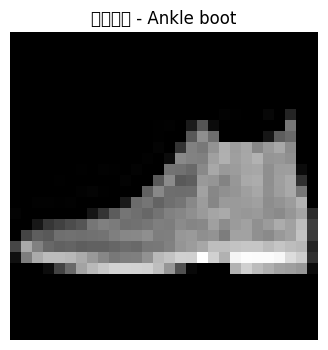

卷积层名称: ['conv2d', 'conv2d_1', 'conv2d_2']
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 121ms/step


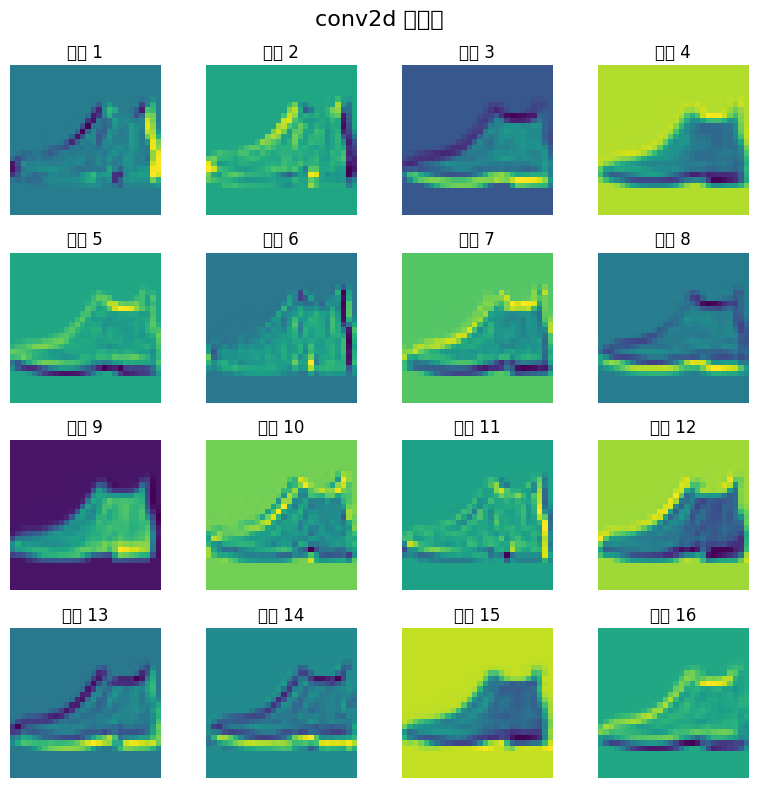

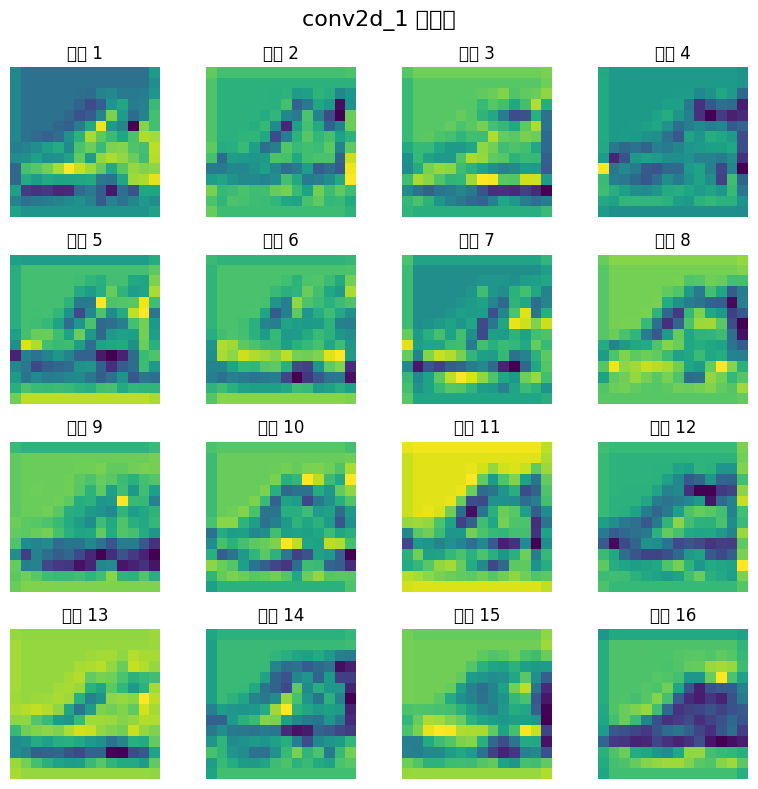

In [ ]:
# 创建特征图可视化函数
def visualize_feature_maps(model, image, layer_names):
    """
    可视化指定层的特征图

    Args:
        model: 训练好的模型
        image: 输入图像 (1, 28, 28, 1)
        layer_names: 要可视化的层名称列表
    """
    # 创建新模型，输出指定层的激活值
    layer_outputs = [model.get_layer(name).output for name in layer_names]
    activation_model = models.Model(inputs=model.input, outputs=layer_outputs)

    # 获取激活值
    activations = activation_model.predict(image)

    # 可视化每一层的特征图
    for layer_name, layer_activation in zip(layer_names, activations):
        n_features = layer_activation.shape[-1]  # 特征图数量
        size = layer_activation.shape[1]         # 特征图大小

        # 显示前 16 个特征图
        display_grid = min(16, n_features)
        cols = 4
        rows = display_grid // cols

        fig, axes = plt.subplots(rows, cols, figsize=(cols * 2, rows * 2))
        fig.suptitle(f'{layer_name} 特征图', fontsize=16)

        for i in range(display_grid):
            row = i // cols
            col = i % cols

            feature_map = layer_activation[0, :, :, i]
            axes[row, col].imshow(feature_map, cmap='viridis')
            axes[row, col].set_title(f'特征 {i+1}')
            axes[row, col].axis('off')

        plt.tight_layout()
        plt.show()

# 选择一张测试图像进行可视化
sample_image = x_test[0:1]  # 选择第一张图像，保持 batch 维度
sample_label = y_test[0]

# 显示原始图像
plt.figure(figsize=(4, 4))
plt.imshow(sample_image[0].squeeze(), cmap='gray')
plt.title(f'原始图像 - {class_names[sample_label]}')
plt.axis('off')
plt.show()

# 获取模型中卷积层的名称
conv_layer_names = [layer.name for layer in best_model.layers
                   if isinstance(layer, layers.Conv2D)]
print(f'卷积层名称: {conv_layer_names}')

# 可视化特征图（只显示前两个卷积层以节省空间）
if len(conv_layer_names) >= 2:
    visualize_feature_maps(best_model, sample_image, conv_layer_names[:2])

## 18. 总结与下一步

通过本教程，我们完成了以下内容：

### 主要成果
1. **数据处理**: 使用 Keras 内置数据集加载和预处理 Fashion-MNIST
2. **模型构建**: 使用函数式 API 构建灵活的 CNN 架构
3. **训练优化**: 利用 Keras 回调函数实现高级训练策略
4. **性能评估**: 全面评估模型性能并可视化结果
5. **模型微调**: 实验数据增强、不同优化器等改进技术
6. **模型解释**: 通过特征图可视化理解 CNN 的工作原理

### TensorFlow/Keras 的优势
- **简洁的 API**: Keras 提供了直观易用的高级 API
- **强大的回调系统**: 轻松实现模型检查点、早停、学习率调度等
- **内置数据增强**: ImageDataGenerator 提供丰富的数据增强选项
- **模型可视化**: 方便的特征图可视化和模型结构展示
- **生产就绪**: TensorFlow 生态系统支持模型部署和服务

### 可能的改进方向
1. **高级架构**
   - 实现 ResNet、DenseNet 等现代架构
   - 使用 Keras Applications 中的预训练模型
   - 尝试 EfficientNet、Vision Transformer 等新架构

2. **训练策略**
   - 实现混合精度训练以提高速度
   - 使用学习率预热和余弦退火
   - 尝试渐进式调整大小训练

3. **正则化技术**
   - 实现 Cutout、MixUp、CutMix 等高级数据增强
   - 使用标签平滑和知识蒸馏
   - 尝试 Stochastic Weight Averaging (SWA)

4. **模型部署**
   - 使用 TensorFlow Lite 进行移动端部署
   - 通过 TensorFlow Serving 部署模型服务
   - 使用 TensorRT 优化推理性能

In [ ]:
# 最终模型性能总结
print('Fashion-MNIST CNN 分类器 - TensorFlow/Keras 实现总结')
print('=' * 70)
print(f'TensorFlow 版本: {tf.__version__}')
print(f'数据集: Fashion-MNIST (60,000 训练样本, 10,000 测试样本)')
print(f'模型参数: {total_params:,}')
print(f'批次大小: {batch_size}')
print(f'训练设备: {"GPU" if len(tf.config.list_physical_devices("GPU")) > 0 else "CPU"}')

print('\n性能结果:')
print(f'原始模型测试准确率: {test_accuracy*100:.2f}%')
if 'test_accuracy_aug' in locals():
    print(f'数据增强模型测试准确率: {test_accuracy_aug*100:.2f}%')
if 'best_optimizer' in locals():
    print(f'最佳优化器: {best_optimizer}')

print('\n主要特性:')
print('- 使用 Keras 函数式 API 构建灵活的 CNN')
print('- 集成批标准化和 Dropout 正则化')
print('- 实现完整的回调函数系统')
print('- 支持数据增强和多种优化器')
print('- 包含特征图可视化和模型解释')
print('\n这个结果展示了 TensorFlow/Keras 在深度学习任务中的强大能力！')